# 06 -- Backtest
CAGR / Sharpe / drawdown per variant; benchmark comparison; stress tests.

In [1]:
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')
os.makedirs('../reports', exist_ok=True)

weights = pd.read_parquet('../data/processed/portfolio_weights_monthly.parquet')
art     = pd.read_parquet('../data/processed/panel_artemis_daily.parquet')
uni     = pd.read_parquet('../data/processed/universe_monthly.parquet')

for df in [weights, art, uni]:
    df['date'] = pd.to_datetime(df['date'])

art = art.sort_values(['symbol', 'date'])
price_w = art.pivot_table(index='date', columns='symbol', values='price', aggfunc='last')
mc_w    = art.pivot_table(index='date', columns='symbol', values='mc',    aggfunc='last')

rebalance_dates = sorted(uni['date'].unique())
variants        = sorted(weights['variant'].unique().tolist())
print(f"Variants: {variants}")
print(f"Rebalance dates: {len(rebalance_dates)}")

def last_val(wide, t, cols):
    sub = wide.reindex(columns=cols).loc[:t]
    if len(sub) == 0:
        return pd.Series(np.nan, index=cols)
    return sub.ffill().iloc[-1]


Variants: ['v1_momentum', 'v2_fund_usage', 'v3_full', 'v4_full_cluster']
Rebalance dates: 48


In [2]:
## Forward returns for all symbols and benchmarks

all_syms = sorted(weights['symbol'].unique())
fwd_map  = {}   # t -> Series(symbol -> fwd_ret)

for i, t in enumerate(rebalance_dates[:-1]):
    t_next = rebalance_dates[i + 1]
    syms   = [s for s in all_syms if s in price_w.columns]
    p_t    = last_val(price_w, t,      syms)
    p_t1   = last_val(price_w, t_next, syms)
    fwd_map[t] = (p_t1 / p_t.replace(0, np.nan)) - 1

# BTC benchmark
btc_rets = {}
for i, t in enumerate(rebalance_dates[:-1]):
    t_next = rebalance_dates[i + 1]
    if 'BTC' in price_w.columns:
        p_t  = last_val(price_w, t,      ['BTC']).iloc[0]
        p_t1 = last_val(price_w, t_next, ['BTC']).iloc[0]
        btc_rets[t] = float((p_t1 / p_t) - 1) if (pd.notna(p_t) and p_t > 0) else np.nan
    else:
        btc_rets[t] = np.nan

# Equal-weight top-50 benchmark
ew_rets = {}
for i, t in enumerate(rebalance_dates[:-1]):
    t_next   = rebalance_dates[i + 1]
    uni_syms = [s for s in uni[uni['date'] == t]['symbol'].tolist() if s in price_w.columns]
    p_t  = last_val(price_w, t,      uni_syms)
    p_t1 = last_val(price_w, t_next, uni_syms)
    ret  = (p_t1 / p_t.replace(0, np.nan)) - 1
    ew_rets[t] = float(ret.mean())

print("BTC sample:", {str(k.date()): round(v, 3) for k, v in list(btc_rets.items())[:4]})
print("EW  sample:", {str(k.date()): round(v, 3) for k, v in list(ew_rets.items())[:4]})


BTC sample: {'2021-01-31': 0.36, '2021-02-28': 0.308, '2021-03-31': -0.017, '2021-04-30': -0.354}
EW  sample: {'2021-01-31': 0.815, '2021-02-28': 0.804, '2021-03-31': 0.481, '2021-04-30': -0.318}


In [3]:
## Portfolio return computation

def compute_returns(weights_df, fwd_map, cost_bps=0, lag_periods=0,
                    exclude_top_n_mcap=0):
    port_rets = {}
    # Sorted weight dates for lag lookup
    all_dates = sorted(weights_df['date'].unique().tolist())
    date_to_idx = {d: i for i, d in enumerate(all_dates)}

    for variant in weights_df['variant'].unique():
        v_df = weights_df[weights_df['variant'] == variant].copy()
        monthly_rets = []
        prev_weights = None

        for i, t in enumerate(rebalance_dates[:-1]):
            fwd = fwd_map.get(t)
            if fwd is None:
                continue

            # For lag stress test: use weights from lag_periods earlier rebalance
            # (simulates data delay -- avoids any look-ahead)
            if lag_periods > 0 and t in date_to_idx:
                w_idx  = max(0, date_to_idx[t] - lag_periods)
                w_date = all_dates[w_idx]
            else:
                w_date = t

            w_t = v_df[v_df['date'] == w_date].set_index('symbol')['weight'].copy()

            if exclude_top_n_mcap > 0:
                mc_t     = last_val(mc_w, t, w_t.index.tolist())
                top_syms = mc_t.nlargest(exclude_top_n_mcap).index.tolist()
                w_t      = w_t.drop(labels=top_syms, errors='ignore')
                longs    = w_t[w_t > 0]
                shorts   = w_t[w_t < 0]
                if len(longs):  w_t[longs.index]  = longs  / longs.sum()
                if len(shorts): w_t[shorts.index]  = shorts / shorts.abs().sum() * -1

            if len(w_t) == 0:
                monthly_rets.append(0.0)
                continue

            # Transaction cost: one-way cost on turnover
            cost = 0.0
            if cost_bps > 0 and prev_weights is not None:
                prev     = prev_weights.reindex(w_t.index).fillna(0)
                turnover = (w_t - prev).abs().sum() / 2
                cost     = turnover * cost_bps / 10_000

            fwd_a = fwd.reindex(w_t.index).fillna(0)
            ret   = float((w_t * fwd_a).sum()) - cost
            monthly_rets.append(ret)
            prev_weights = w_t

        n = len(monthly_rets)
        port_rets[variant] = pd.Series(
            monthly_rets, index=rebalance_dates[:n])

    return port_rets

base_rets = compute_returns(weights, fwd_map)
print("Base portfolio returns computed:")
for v, r in sorted(base_rets.items()):
    print(f"  {v}: n={len(r)}, mean={r.mean():.4f}, std={r.std():.4f}")


Base portfolio returns computed:
  v1_momentum: n=47, mean=0.0377, std=0.1589
  v2_fund_usage: n=47, mean=0.0347, std=0.2231
  v3_full: n=47, mean=0.0243, std=0.2119
  v4_full_cluster: n=47, mean=0.0187, std=0.1941


In [4]:
## Performance metrics

def metrics(rets_series, periods_per_year=12):
    r = rets_series.dropna()
    if len(r) < 2:
        return {k: np.nan for k in ['CAGR', 'Ann Vol', 'Sharpe', 'Max DD', 'Hit Rate', 'N']}
    cagr  = (1 + r).prod() ** (periods_per_year / len(r)) - 1
    vol   = r.std() * np.sqrt(periods_per_year)
    sr    = cagr / vol if vol > 1e-10 else np.nan
    cum   = (1 + r).cumprod()
    maxdd = (cum / cum.cummax() - 1).min()
    hit   = (r > 0).mean()
    return {'CAGR': cagr, 'Ann Vol': vol, 'Sharpe': sr,
            'Max DD': maxdd, 'Hit Rate': hit, 'N': len(r)}

btc_s = pd.Series(btc_rets).dropna()
ew_s  = pd.Series(ew_rets).dropna()

rows = []
for v, r in sorted(base_rets.items()):
    m = metrics(r); m['Strategy'] = v; rows.append(m)
for name, s in [('BTC buy-hold', btc_s), ('EW top-50', ew_s)]:
    m = metrics(s); m['Strategy'] = name; rows.append(m)

perf = pd.DataFrame(rows).set_index('Strategy')

def fmt(df):
    d = df.copy()
    for col in ['CAGR', 'Ann Vol', 'Max DD']:
        d[col] = d[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else 'n/a')
    d['Sharpe']   = d['Sharpe'].map(lambda x: f"{x:.2f}" if pd.notna(x) else 'n/a')
    d['Hit Rate'] = d['Hit Rate'].map(lambda x: f"{x:.1%}" if pd.notna(x) else 'n/a')
    d['N']        = d['N'].astype(int)
    return d

print("\n=== Base Performance Metrics ===")
print(fmt(perf)[['CAGR', 'Ann Vol', 'Sharpe', 'Max DD', 'Hit Rate', 'N']].to_string())



=== Base Performance Metrics ===
                  CAGR Ann Vol Sharpe  Max DD Hit Rate   N
Strategy                                                  
v1_momentum      34.5%   55.1%   0.63  -57.0%    63.8%  47
v2_fund_usage    -1.8%   77.3%  -0.02  -86.3%    59.6%  47
v3_full          -7.4%   73.4%  -0.10  -79.1%    66.0%  47
v4_full_cluster  -4.1%   67.3%  -0.06  -62.9%    63.8%  47
BTC buy-hold     30.4%   65.7%   0.46  -73.1%    55.3%  47
EW top-50        41.9%  103.3%   0.41  -81.1%    48.9%  47


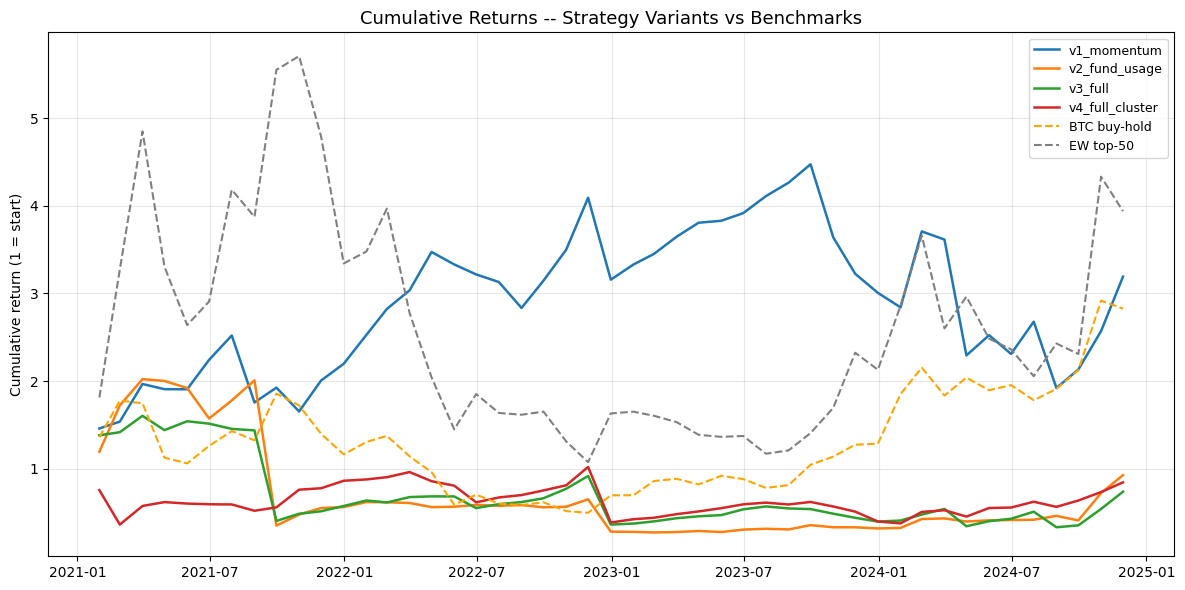

Saved: reports/cumulative_returns.png


In [5]:
## Cumulative return chart
colors = plt.cm.tab10.colors

# Align all series to the same date index
date_idx = list(base_rets.values())[0].index

fig, ax = plt.subplots(figsize=(12, 6))
for (v, r), col in zip(sorted(base_rets.items()), colors[:4]):
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, label=v, lw=1.8, color=col)

cum_btc = (1 + btc_s.reindex(date_idx).fillna(0)).cumprod()
cum_ew  = (1 + ew_s.reindex(date_idx).fillna(0)).cumprod()
ax.plot(cum_btc.index, cum_btc.values, label='BTC buy-hold', lw=1.5, ls='--', color='orange')
ax.plot(cum_ew.index,  cum_ew.values,  label='EW top-50',    lw=1.5, ls='--', color='grey')

ax.set_title('Cumulative Returns -- Strategy Variants vs Benchmarks', fontsize=13)
ax.set_ylabel('Cumulative return (1 = start)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('../reports/cumulative_returns.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: reports/cumulative_returns.png")


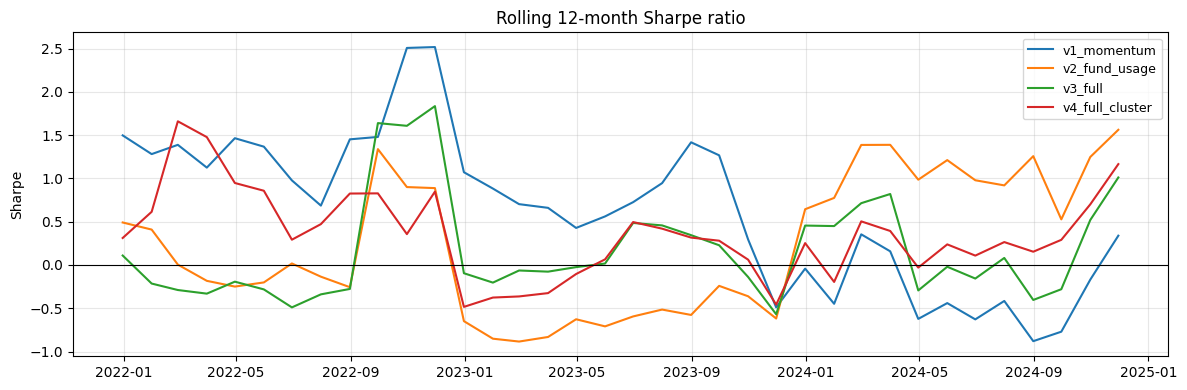


=== Annual Returns ===
                   2021    2022   2023    2024
v1_momentum      119.9%   43.6%  -4.8%    6.1%
v2_fund_usage    -43.4%  -49.5%  12.8%  188.6%
v3_full          -42.2%  -36.6%   9.4%   85.0%
v4_full_cluster  -13.4%  -55.0%   2.9%  111.3%
BTC               16.6%  -40.0%  84.0%  119.6%
EW top-50        234.3%  -51.2%  30.5%   84.9%


In [6]:
## Rolling 12-month Sharpe
fig, ax = plt.subplots(figsize=(12, 4))
for (v, r), col in zip(sorted(base_rets.items()), colors[:4]):
    roll_sr = r.rolling(12).apply(
        lambda x: x.mean() / x.std() * np.sqrt(12) if x.std() > 1e-10 else 0.0)
    ax.plot(roll_sr.index, roll_sr.values, label=v, lw=1.5, color=col)
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Rolling 12-month Sharpe ratio'); ax.set_ylabel('Sharpe')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Annual return table
print("\n=== Annual Returns ===")
ann_rows = {}
for v, r in sorted(base_rets.items()):
    ann_rows[v] = r.groupby(r.index.year).apply(lambda x: (1 + x).prod() - 1)
for name, s in [('BTC', btc_s), ('EW top-50', ew_s)]:
    ann_rows[name] = s.groupby(s.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_df = pd.DataFrame(ann_rows).T
print(annual_df.map(lambda x: f"{x:.1%}" if pd.notna(x) else 'n/a').to_string())


In [7]:
## Stress tests

# (a) Lag signals by 1 period (~1 month) to simulate 3-day fundamental data delay
lag_rets  = compute_returns(weights, fwd_map, lag_periods=1)

# (b) 10 bps one-way transaction cost
cost_rets = compute_returns(weights, fwd_map, cost_bps=10)

# (c) Exclude top-5 coins by market cap
excl_rets = compute_returns(weights, fwd_map, exclude_top_n_mcap=5)

scenarios = {
    'Base':            base_rets,
    'Lag signals 1m':  lag_rets,
    '+10bps cost':     cost_rets,
    'Excl top-5 mc':   excl_rets,
}

print("\n=== Stress Tests -- v3_full composite ===")
stress_rows = []
for scenario, rd in scenarios.items():
    r = rd.get('v3_full', pd.Series(dtype=float))
    m = metrics(r); m['Scenario'] = scenario; stress_rows.append(m)

stress_df = pd.DataFrame(stress_rows).set_index('Scenario')
print(fmt(stress_df)[['CAGR', 'Ann Vol', 'Sharpe', 'Max DD', 'Hit Rate']].to_string())



=== Stress Tests -- v3_full composite ===
                 CAGR Ann Vol Sharpe   Max DD Hit Rate
Scenario                                              
Base            -7.4%   73.4%  -0.10   -79.1%    66.0%
Lag signals 1m    n/a  105.5%    n/a  -103.5%    57.4%
+10bps cost     -8.7%   73.4%  -0.12   -80.2%    66.0%
Excl top-5 mc    7.8%  210.9%   0.04   -99.1%    46.8%


In [8]:
## BTC regime analysis (loose = BTC 90d return > 0, tight = <=0)
print("\n=== BTC Regime Analysis -- v3_full ===")
v3 = base_rets.get('v3_full', pd.Series(dtype=float))

btc_price_s = None
if 'BTC' in art['symbol'].values:
    btc_price_s = art[art['symbol'] == 'BTC'].set_index('date')['price']

regime = {'Loose (BTC 90d>0)': [], 'Tight (BTC 90d<=0)': []}
for t, r in v3.items():
    key = 'Loose (BTC 90d>0)'
    if btc_price_s is not None:
        t_90     = t - pd.Timedelta(days=90)
        btc_now  = btc_price_s.loc[:t].iloc[-1]  if len(btc_price_s.loc[:t])  else np.nan
        btc_90   = btc_price_s.loc[:t_90].iloc[-1] if len(btc_price_s.loc[:t_90]) else np.nan
        if pd.notna(btc_now) and pd.notna(btc_90) and btc_90 > 0:
            key = 'Loose (BTC 90d>0)' if (btc_now / btc_90 - 1) > 0 else 'Tight (BTC 90d<=0)'
    regime[key].append(r)

for key, rets in regime.items():
    if rets:
        s  = pd.Series(rets)
        sr = s.mean() / s.std() * np.sqrt(12) if s.std() > 0 else np.nan
        print(f"  {key}: n={len(s)}, mean ret={s.mean():.2%}, Sharpe={sr:.2f}")



=== BTC Regime Analysis -- v3_full ===
  Loose (BTC 90d>0): n=28, mean ret=5.30%, Sharpe=0.81
  Tight (BTC 90d<=0): n=19, mean ret=-1.80%, Sharpe=-0.33


In [9]:
## Final summary
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
print(fmt(perf)[['CAGR', 'Ann Vol', 'Sharpe', 'Max DD', 'Hit Rate']].to_string())
print("\n>> Backtest complete.")



FINAL PERFORMANCE SUMMARY
                  CAGR Ann Vol Sharpe  Max DD Hit Rate
Strategy                                              
v1_momentum      34.5%   55.1%   0.63  -57.0%    63.8%
v2_fund_usage    -1.8%   77.3%  -0.02  -86.3%    59.6%
v3_full          -7.4%   73.4%  -0.10  -79.1%    66.0%
v4_full_cluster  -4.1%   67.3%  -0.06  -62.9%    63.8%
BTC buy-hold     30.4%   65.7%   0.46  -73.1%    55.3%
EW top-50        41.9%  103.3%   0.41  -81.1%    48.9%

>> Backtest complete.
